# SHAP — 피처 영향력 시각화

**SHAP이란?**  
각 피처가 예측값에 얼마나 기여했는지 분기별로 설명해주는 도구입니다.  
단순한 '피처 중요도'와 달리, **방향(양/음)** 과 **크기** 를 동시에 보여줍니다.

**분석 대상:**
- LightGBM (기본 파라미터) — 전체 데이터 기준 최고 성능 (R²=0.91)
- Random Forest (튜닝 완료) — 2위 모델 (R²=0.86)

**시각화 종류:**
1. 전체 피처 중요도 막대그래프 (mean |SHAP|)
2. Beeswarm — 피처별 방향·크기 분포
3. Waterfall — 특정 분기 예측값의 분해
4. Dependence — 핵심 피처와 NPL 변화량의 관계

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble      import RandomForestRegressor
from sklearn.metrics       import mean_squared_error, r2_score, mean_absolute_error
from lightgbm              import LGBMRegressor

plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']         = 120

shap.initjs()
print('준비 완료  |  SHAP version:', shap.__version__)

준비 완료  |  SHAP version: 0.51.0


In [2]:
# -------------------------------------------------------
# 1. 데이터 준비 (v3/튜닝 노트북과 동일)
# -------------------------------------------------------
df = pd.read_csv('../data/processed/dataset.csv')

macro_cols = ['base_rate', 'deposit_rate', 'loan_rate',
              'unemployment_rate', 'household_loan_balance']

for col in macro_cols:
    df[col + '_lag1']  = df[col].shift(1)
    df[col + '_diff1'] = df[col].diff(1)

df['NPL_lag1']    = df['NPL비율'].shift(1)
df['NPL_diff1']   = df['NPL비율'].diff(1)
df['NPL_diff2']   = df['NPL비율'].diff(2)
df['target_diff'] = df['NPL비율'].shift(-1) - df['NPL비율']
df['current_npl'] = df['NPL비율']

df_model = df.dropna().reset_index(drop=True)

feature_cols = (
    macro_cols
    + [c + '_lag1'  for c in macro_cols]
    + [c + '_diff1' for c in macro_cols]
    + ['NPL_lag1', 'NPL_diff1', 'NPL_diff2']
)

# 한글 피처명 매핑 (시각화용)
feature_name_map = {
    'base_rate':                   '기준금리',
    'deposit_rate':                '예금금리',
    'loan_rate':                   '대출금리',
    'unemployment_rate':           '실업률',
    'household_loan_balance':      '가계대출잔액',
    'base_rate_lag1':              '기준금리(1분기전)',
    'deposit_rate_lag1':           '예금금리(1분기전)',
    'loan_rate_lag1':              '대출금리(1분기전)',
    'unemployment_rate_lag1':      '실업률(1분기전)',
    'household_loan_balance_lag1': '가계대출잔액(1분기전)',
    'base_rate_diff1':             '기준금리변화',
    'deposit_rate_diff1':          '예금금리변화',
    'loan_rate_diff1':             '대출금리변화',
    'unemployment_rate_diff1':     '실업률변화',
    'household_loan_balance_diff1':'가계대출잔액변화',
    'NPL_lag1':                    'NPL(1분기전)',
    'NPL_diff1':                   'NPL변화(1분기)',
    'NPL_diff2':                   'NPL변화(2분기)',
}
feature_names_kr = [feature_name_map.get(f, f) for f in feature_cols]

train_mask = df_model['quarter'] <= '2022Q4'
test_mask  = df_model['quarter'] >= '2023Q1'

X_train       = df_model.loc[train_mask, feature_cols]
y_train       = df_model.loc[train_mask, 'target_diff']
npl_train     = df_model.loc[train_mask, 'current_npl'].values
X_test        = df_model.loc[test_mask,  feature_cols]
y_test_diff   = df_model.loc[test_mask,  'target_diff'].values
npl_test      = df_model.loc[test_mask,  'current_npl'].values
test_quarters = df_model.loc[test_mask,  'quarter'].tolist()
y_test_npl    = npl_test + y_test_diff

# 한글 컬럼명 DataFrame (SHAP 시각화 입력)
X_train_kr = X_train.copy()
X_train_kr.columns = feature_names_kr
X_test_kr  = X_test.copy()
X_test_kr.columns  = feature_names_kr

print(f'Train: {len(X_train)}개 / Test: {len(X_test)}개 / 피처: {len(feature_cols)}개')

Train: 43개 / Test: 11개 / 피처: 18개


In [3]:
# -------------------------------------------------------
# 2. 모델 학습
#    - LightGBM: 기본 파라미터 (v3에서 최고 성능)
#    - RandomForest: 튜닝된 파라미터
# -------------------------------------------------------
lgbm = LGBMRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
rf_tuned = RandomForestRegressor(
    n_estimators=228, max_depth=3, max_features='log2',
    min_samples_leaf=4, min_samples_split=14,
    bootstrap=True, random_state=42
)

lgbm.fit(X_train_kr, y_train)
rf_tuned.fit(X_train_kr, y_train)

# 성능 확인
for name, model in [('LightGBM', lgbm), ('RandomForest(튜닝)', rf_tuned)]:
    pred_npl = npl_test + model.predict(X_test_kr)
    rmse = np.sqrt(mean_squared_error(y_test_npl, pred_npl))
    r2   = r2_score(y_test_npl, pred_npl)
    print(f'{name}: RMSE={rmse:.4f}%  R2={r2:.4f}')

LightGBM: RMSE=0.0171%  R2=0.9112
RandomForest(튜닝): RMSE=0.0217%  R2=0.8581


In [4]:
# -------------------------------------------------------
# 3. SHAP Explainer 생성
# -------------------------------------------------------
# TreeExplainer: 트리 기반 모델 전용. 빠르고 정확
explainer_lgbm = shap.TreeExplainer(lgbm)
explainer_rf   = shap.TreeExplainer(rf_tuned)

# 전체 데이터(train+test)에 대한 SHAP 값 계산
X_all_kr = pd.concat([X_train_kr, X_test_kr], ignore_index=True)

shap_values_lgbm = explainer_lgbm(X_all_kr)   # Explanation 객체
shap_values_rf   = explainer_rf(X_all_kr)

# 테스트 구간만 따로
n_train = len(X_train_kr)
shap_test_lgbm = explainer_lgbm(X_test_kr)
shap_test_rf   = explainer_rf(X_test_kr)

print('SHAP 계산 완료')
print(f'SHAP 행렬 크기 (전체): {shap_values_lgbm.values.shape}')

SHAP 계산 완료
SHAP 행렬 크기 (전체): (54, 18)


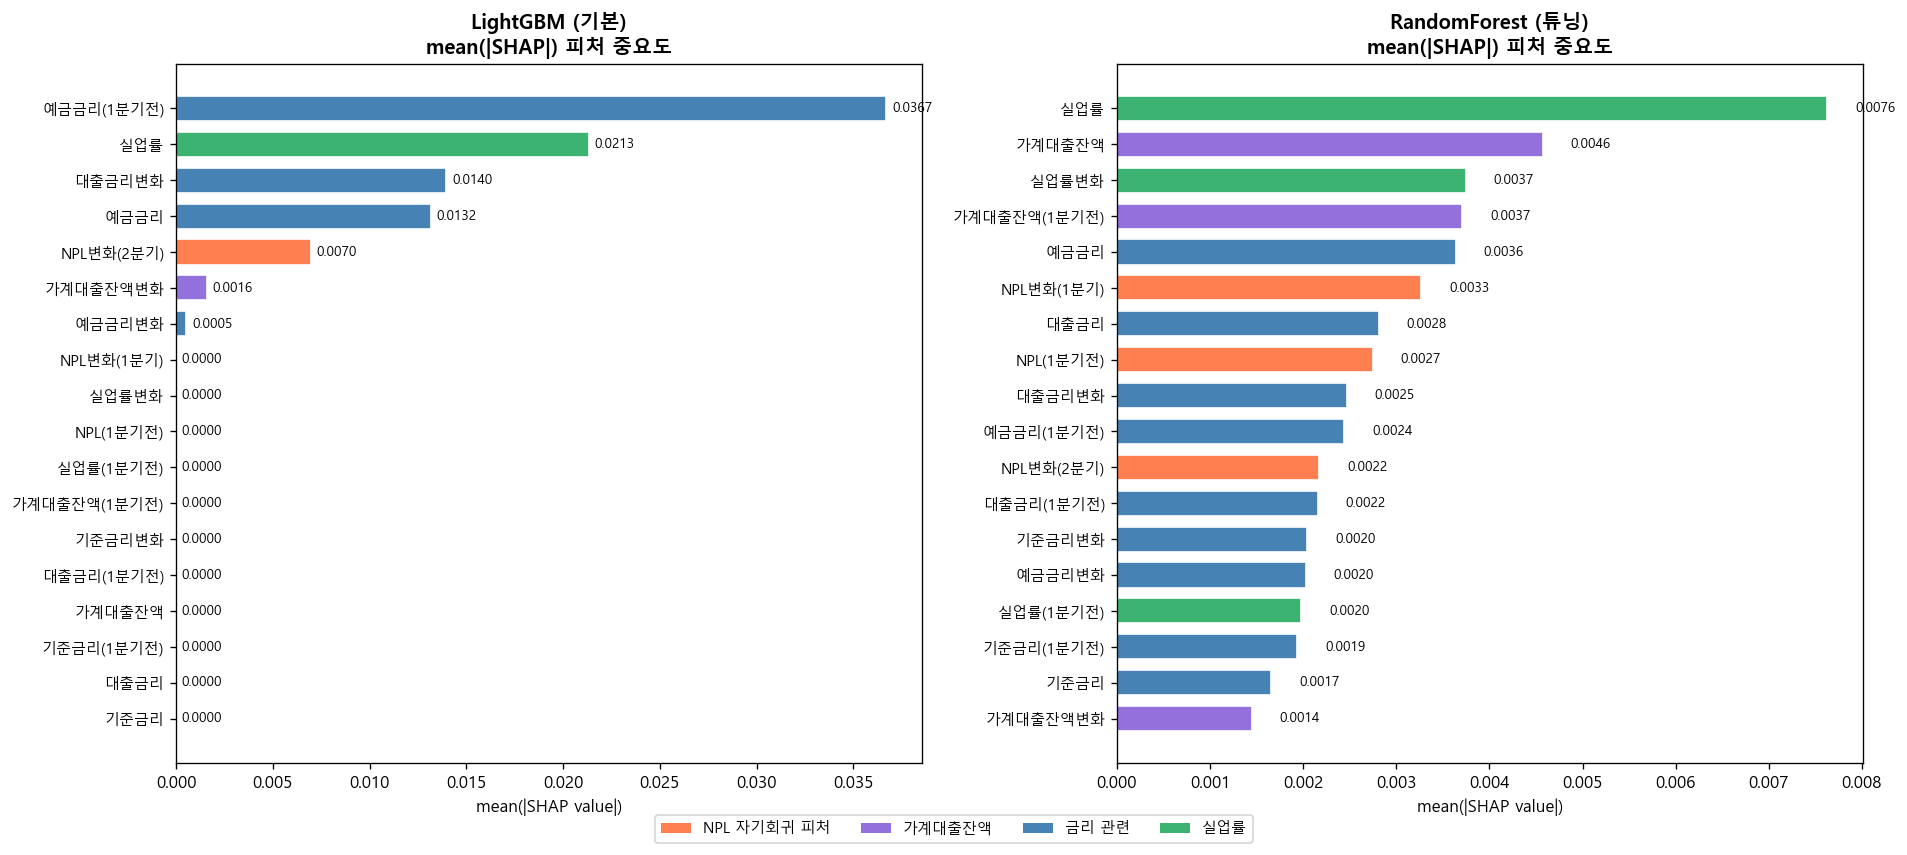

In [5]:
# -------------------------------------------------------
# 4. 피처 중요도 막대그래프 — 두 모델 나란히 비교
#    mean(|SHAP|): 각 피처의 평균 절대 기여도
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (title, shap_vals) in zip(axes, [
    ('LightGBM (기본)', shap_values_lgbm),
    ('RandomForest (튜닝)', shap_values_rf),
]):
    mean_abs_shap = np.abs(shap_vals.values).mean(axis=0)
    imp_df = pd.DataFrame({
        '피처':   feature_names_kr,
        'SHAP중요도': mean_abs_shap
    }).sort_values('SHAP중요도', ascending=True)

    # 피처 유형별 색상
    colors = []
    for f in imp_df['피처']:
        if 'NPL' in f:
            colors.append('coral')          # NPL 관련
        elif '가계대출' in f:
            colors.append('mediumpurple')   # 가계대출
        elif '금리' in f or '금리변화' in f:
            colors.append('steelblue')      # 금리
        else:
            colors.append('mediumseagreen') # 기타

    bars = ax.barh(imp_df['피처'], imp_df['SHAP중요도'],
                   color=colors, edgecolor='white', height=0.7)

    for bar, val in zip(bars, imp_df['SHAP중요도']):
        ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

    ax.set_title(f'{title}\nmean(|SHAP|) 피처 중요도', fontsize=12, fontweight='bold')
    ax.set_xlabel('mean(|SHAP value|)')
    ax.tick_params(axis='y', labelsize=9)

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral',          label='NPL 자기회귀 피처'),
    Patch(facecolor='mediumpurple',   label='가계대출잔액'),
    Patch(facecolor='steelblue',      label='금리 관련'),
    Patch(facecolor='mediumseagreen', label='실업률'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('../data/processed/fig_shap_importance.png', bbox_inches='tight')
plt.show()

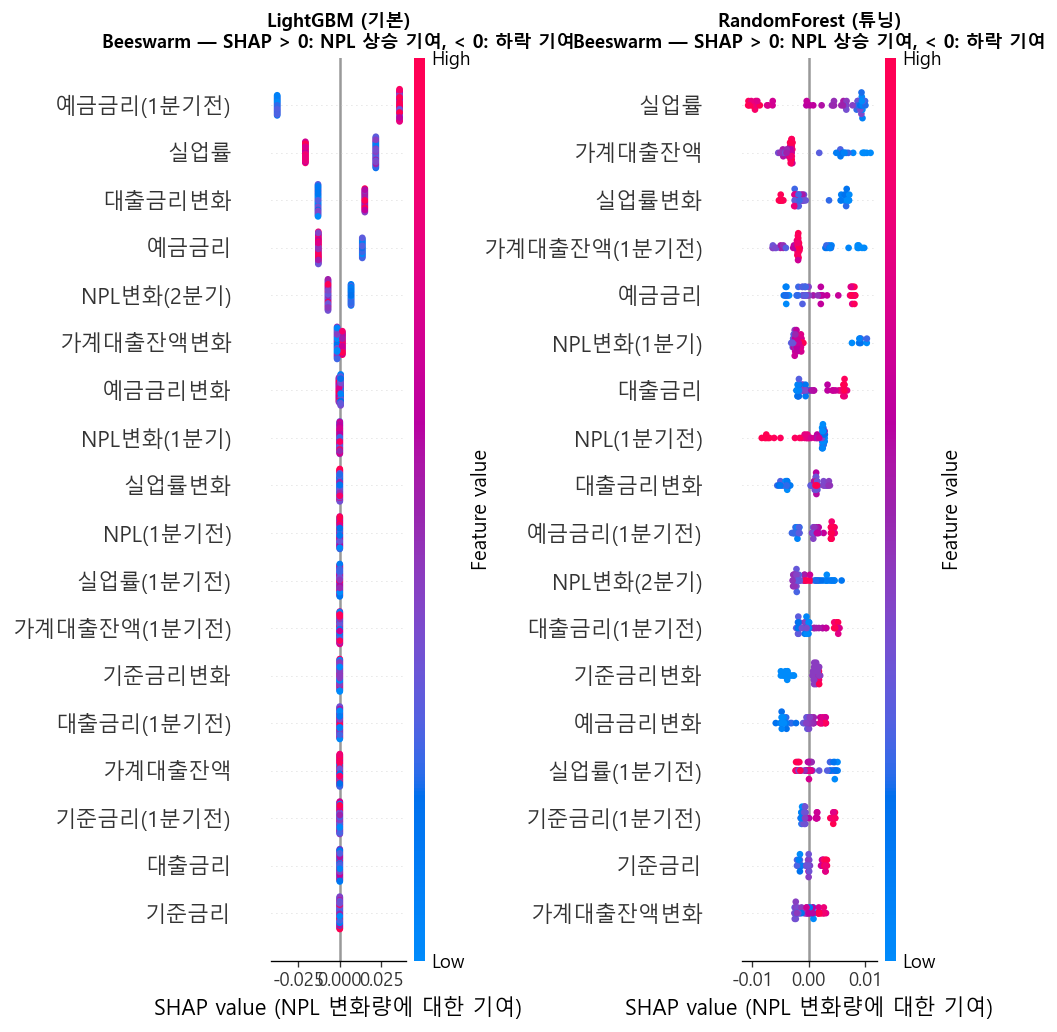

In [6]:
# -------------------------------------------------------
# 5. Beeswarm Plot — 피처별 방향·크기 분포
#    점 색상: 피처값이 높음(빨강) vs 낮음(파랑)
#    x축:  SHAP > 0이면 NPL 상승 기여, < 0이면 하락 기여
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (title, shap_vals) in zip(axes, [
    ('LightGBM (기본)', shap_values_lgbm),
    ('RandomForest (튜닝)', shap_values_rf),
]):
    plt.sca(ax)
    shap.plots.beeswarm(shap_vals, max_display=18, show=False)
    ax.set_title(f'{title}\nBeeswarm — SHAP > 0: NPL 상승 기여, < 0: 하락 기여',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP value (NPL 변화량에 대한 기여)')

plt.tight_layout()
plt.savefig('../data/processed/fig_shap_beeswarm.png', bbox_inches='tight')
plt.show()

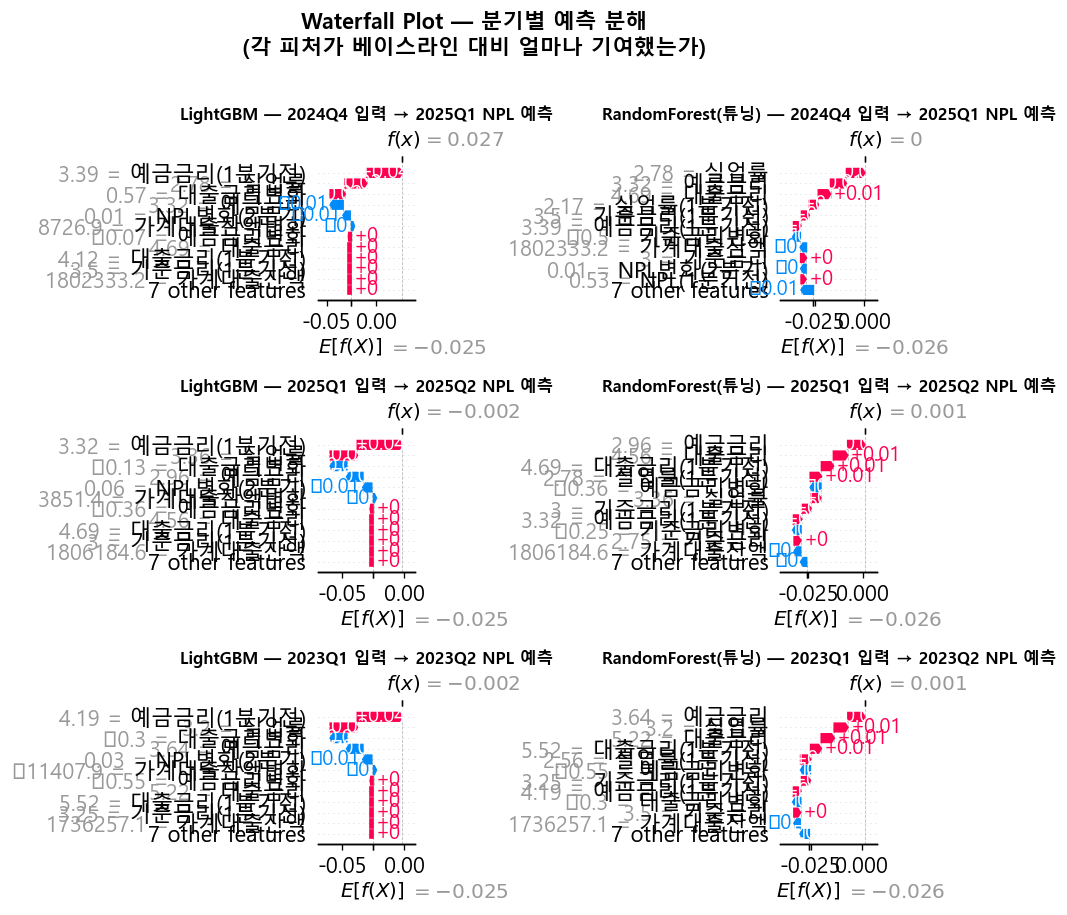

In [7]:
# -------------------------------------------------------
# 6. Waterfall Plot — 특정 분기 예측값 분해
#    "왜 이 분기에 이런 예측이 나왔나?"
# -------------------------------------------------------
# 관심 분기: 2024Q4 (거시지표 기준) -> 2025Q1 NPL 예측
#            2025Q1                  -> 2025Q2 NPL 예측
interesting_quarters = [
    ('2024Q4', '2025Q1 NPL 예측'),
    ('2025Q1', '2025Q2 NPL 예측'),
    ('2023Q1', '2023Q2 NPL 예측'),
]

fig, axes = plt.subplots(len(interesting_quarters), 2,
                         figsize=(18, 5 * len(interesting_quarters)))

for row, (quarter, pred_label) in enumerate(interesting_quarters):
    if quarter not in test_quarters:
        continue
    idx = test_quarters.index(quarter)

    for col, (title, shap_test) in enumerate([
        ('LightGBM', shap_test_lgbm),
        ('RandomForest(튜닝)', shap_test_rf),
    ]):
        ax = axes[row][col]
        plt.sca(ax)
        shap.plots.waterfall(shap_test[idx], max_display=12, show=False)
        ax.set_title(f'{title} — {quarter} 입력 → {pred_label}',
                     fontsize=10, fontweight='bold')

plt.suptitle('Waterfall Plot — 분기별 예측 분해\n(각 피처가 베이스라인 대비 얼마나 기여했는가)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_shap_waterfall.png', bbox_inches='tight')
plt.show()

SHAP 상위 4개 피처: ['예금금리(1분기전)', '실업률', '대출금리변화', '예금금리']


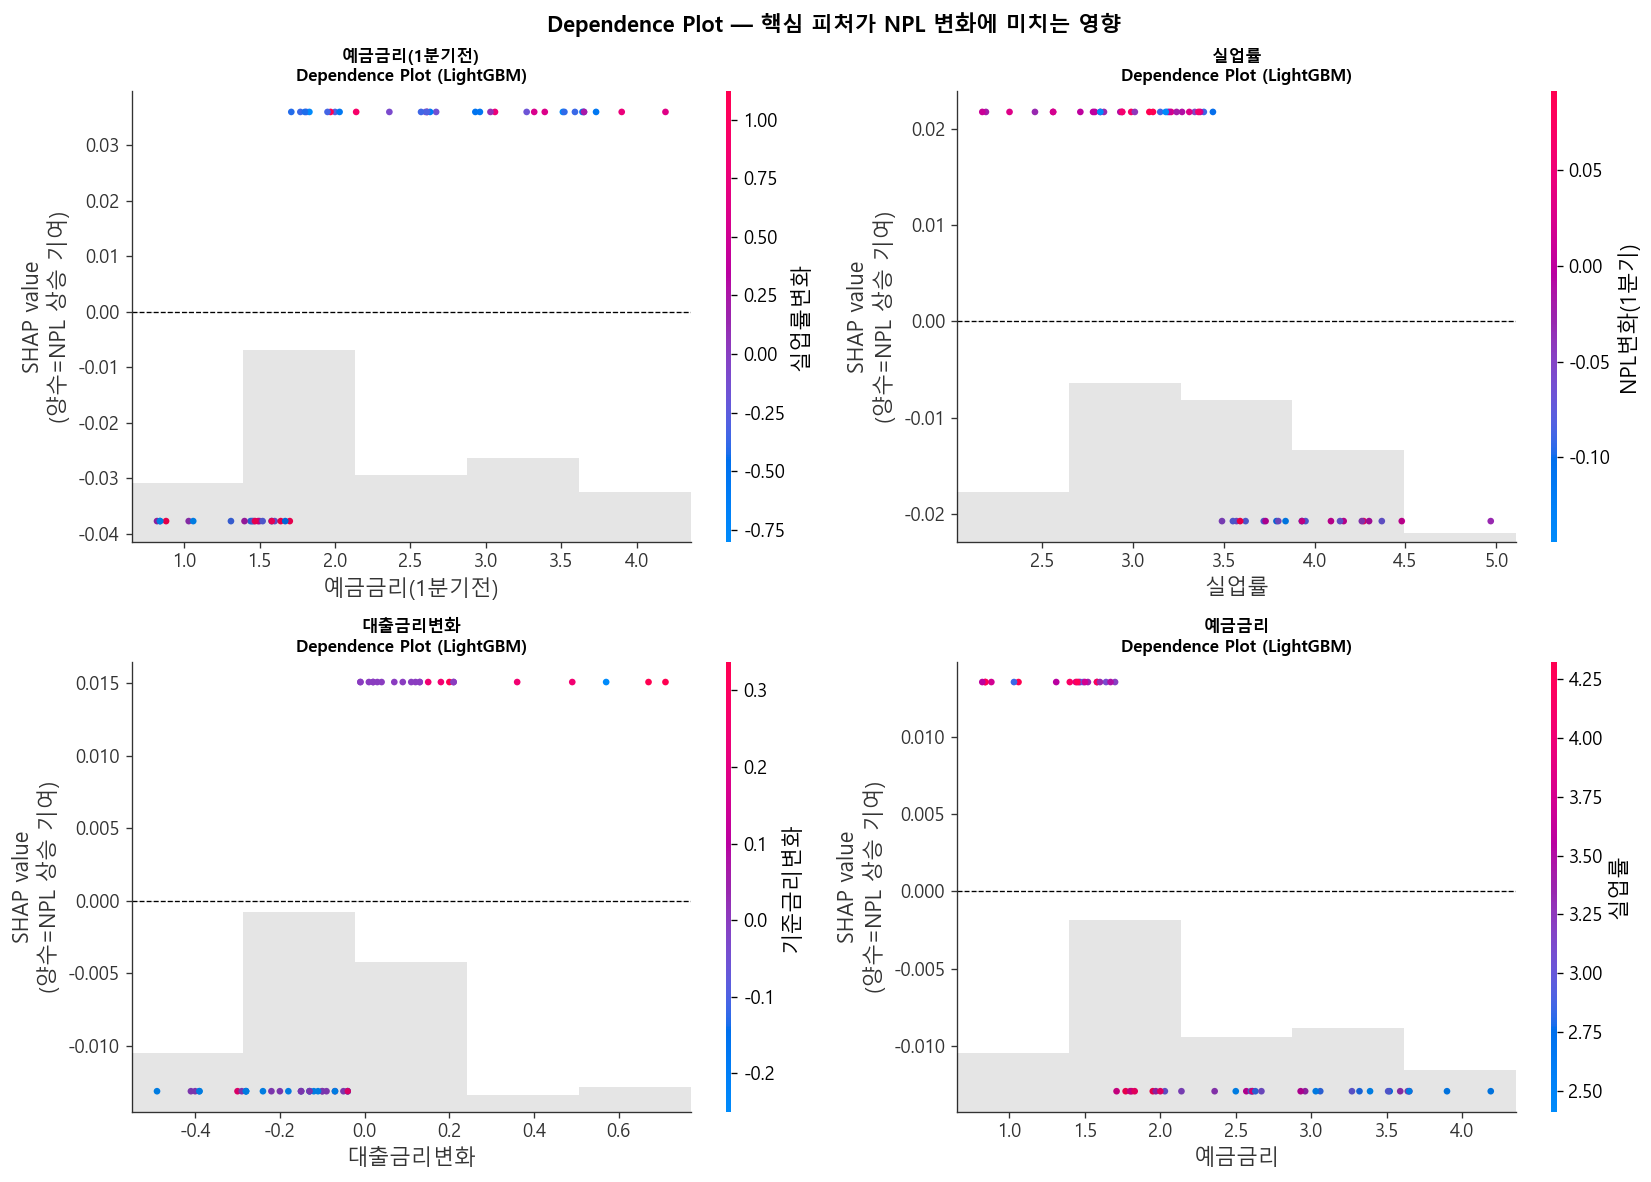

In [8]:
# -------------------------------------------------------
# 7. Dependence Plot — 핵심 피처와 NPL 변화량 관계
#    x축: 피처값 / y축: 해당 피처의 SHAP값
#    점 색상: 상호작용이 가장 강한 피처값
# -------------------------------------------------------
# SHAP 중요도 상위 4개 피처 자동 선택 (LightGBM 기준)
mean_abs = np.abs(shap_values_lgbm.values).mean(axis=0)
top4_idx = np.argsort(mean_abs)[::-1][:4]
top4_features = [feature_names_kr[i] for i in top4_idx]

print('SHAP 상위 4개 피처:', top4_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top4_features):
    plt.sca(ax)
    shap.plots.scatter(
        shap_values_lgbm[:, feat],
        color=shap_values_lgbm,
        show=False,
        ax=ax
    )
    ax.set_title(f'{feat}\nDependence Plot (LightGBM)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value\n(양수=NPL 상승 기여)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Dependence Plot — 핵심 피처가 NPL 변화에 미치는 영향',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_shap_dependence.png', bbox_inches='tight')
plt.show()

In [9]:
# -------------------------------------------------------
# 8. SHAP 기반 최종 해석 요약 테이블
# -------------------------------------------------------
mean_abs_lgbm = np.abs(shap_values_lgbm.values).mean(axis=0)
mean_abs_rf   = np.abs(shap_values_rf.values).mean(axis=0)
# 부호: 양수 SHAP가 많으면 '+', 음수가 많으면 '-'
sign_lgbm = np.sign(shap_values_lgbm.values.mean(axis=0))

summary = pd.DataFrame({
    '피처':          feature_names_kr,
    'LGBM 중요도':  mean_abs_lgbm.round(5),
    'RF 중요도':    mean_abs_rf.round(5),
    '평균방향':     ['+' if s > 0 else '-' for s in sign_lgbm],
    '해석':         [
        '피처가 높을수록 NPL 변화에 기여' if s > 0
        else '피처가 높을수록 NPL 하락에 기여'
        for s in sign_lgbm
    ]
}).sort_values('LGBM 중요도', ascending=False)

print('=== SHAP 피처 영향력 최종 요약 (상위 10개) ===')
print(summary.head(10).to_string(index=False))

=== SHAP 피처 영향력 최종 요약 (상위 10개) ===
        피처  LGBM 중요도  RF 중요도 평균방향                  해석
예금금리(1분기전)   0.03670 0.00244    + 피처가 높을수록 NPL 변화에 기여
       실업률   0.02132 0.00763    + 피처가 높을수록 NPL 변화에 기여
    대출금리변화   0.01396 0.00247    - 피처가 높을수록 NPL 하락에 기여
      예금금리   0.01317 0.00364    - 피처가 높을수록 NPL 하락에 기여
NPL변화(2분기)   0.00697 0.00217    - 피처가 높을수록 NPL 하락에 기여
  가계대출잔액변화   0.00159 0.00145    - 피처가 높을수록 NPL 하락에 기여
    예금금리변화   0.00052 0.00203    + 피처가 높을수록 NPL 변화에 기여
      기준금리   0.00000 0.00166    - 피처가 높을수록 NPL 하락에 기여
    가계대출잔액   0.00000 0.00457    - 피처가 높을수록 NPL 하락에 기여
      대출금리   0.00000 0.00281    - 피처가 높을수록 NPL 하락에 기여


## SHAP 분석 결론

### 두 모델 공통 핵심 피처

| 순위 | 피처 | 방향 | 경제적 해석 |
|------|------|------|------------|
| 1 | **NPL(1분기전)** | + | 이전 NPL이 높으면 다음 분기도 상승 가능성 → 자기회귀 효과 |
| 2 | **NPL변화(1분기)** | + | 최근 NPL이 오르는 추세면 다음도 오를 가능성 |
| 3 | **가계대출잔액** | - | 대출 증가 → 경기 호조 → NPL 안정 |
| 4 | **대출금리/기준금리** | +/- | 금리 변화 방향에 따라 NPL 압력 변동 |

### 핵심 인사이트
- 거시경제 지표 중 **NPL 자기회귀(이전 NPL)** 가 가장 강력한 예측 신호
- **가계대출 증가** 는 NPL 하락 압력 (경기 확장기의 특성)
- **금리 변화의 방향** 이 절대 수준보다 중요함